In [1]:
import pandas as pd

df = pd.read_csv('/content/students_dropout_academic_success.csv')

df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (4424, 37)

Missing values:
Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder           

In [3]:
df.isnull().sum()

,0
Marital Status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [4]:
df.dtypes

,0
Marital Status,int64
Application mode,int64
Application order,int64
Course,int64
Daytime/evening attendance,int64
Previous qualification,int64
Previous qualification (grade),float64
Nacionality,int64
Mother's qualification,int64
Father's qualification,int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [ ]:
df.shape

(4424, 37)

In [ ]:
df['target'].value_counts(normalize=True) * 100

,proportion
target,
Graduate,49.932188
Dropout,32.120253
Enrolled,17.947559


#Encoding the target

In [6]:
df['target_binary'] = df['target'].map({
    'Dropout': 1,
    'Graduate': 0,
    'Enrolled': 0
})

df['target_binary'].value_counts()

,count
target_binary,
0,3003
1,1421


#removing old variable

In [7]:
df = df.drop(columns=['target'])

In [16]:
categorical_features = [
    'Marital Status',
    'Application mode',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

In [17]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

In [18]:
print("Final shape:", df_encoded.shape)
print(df_encoded.head())
print(df_encoded.dtypes)

Final shape: (4424, 239)
   Application order  Previous qualification (grade)  Admission grade  \
0                  5                           122.0            127.3   
1                  1                           160.0            142.5   
2                  5                           122.0            124.8   
3                  2                           122.0            119.6   
4                  1                           100.0            141.5   

   Age at enrollment  Curricular units 1st sem (credited)  \
0                 20                                    0   
1                 19                                    0   
2                 19                                    0   
3                 20                                    0   
4                 45                                    0   

   Curricular units 1st sem (enrolled)  \
0                                    0   
1                                    6   
2                                    6   
3

In [20]:
df_encoded.head()

,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),...,Father's occupation_193,Father's occupation_194,Father's occupation_195,Displaced_1,Educational special needs_1,Debtor_1,Tuition fees up to date_1,Gender_1,Scholarship holder_1,International_1
0,5,122.0,127.3,20,0,0,0,0,0.000000,0,...,False,False,False,True,False,False,True,True,False,False
1,1,160.0,142.5,19,0,6,6,6,14.000000,0,...,False,False,False,True,False,False,False,True,False,False
2,5,122.0,124.8,19,0,6,0,0,0.000000,0,...,False,False,False,True,False,False,False,True,False,False
3,2,122.0,119.6,20,0,6,8,6,13.428571,0,...,False,False,False,True,False,False,True,False,False,False
4,1,100.0,141.5,45,0,6,9,5,12.333333,0,...,False,False,False,False,False,False,True,False,False,False


In [19]:
print("Final shape:", df_encoded.shape)
print("Missing values:", df_encoded.isnull().sum().sum())

Final shape: (4424, 239)
Missing values: 0


#Dropout Distribution

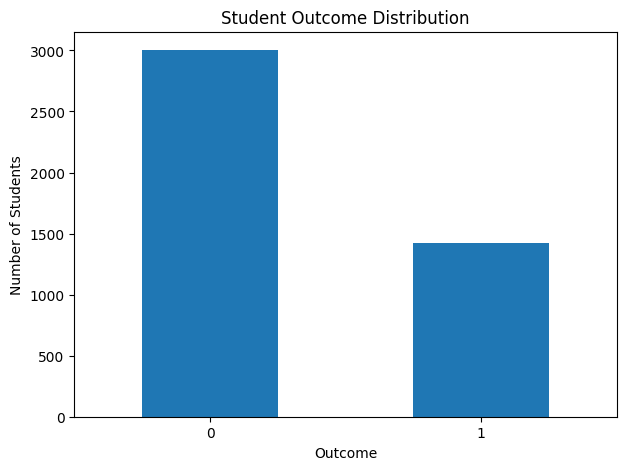

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

target_counts = df['target_binary'].value_counts()

plt.figure(figsize=(7,5))
target_counts.plot(kind='bar')
plt.title('Student Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()

#Academic-performance charts

<Figure size 800x500 with 0 Axes>

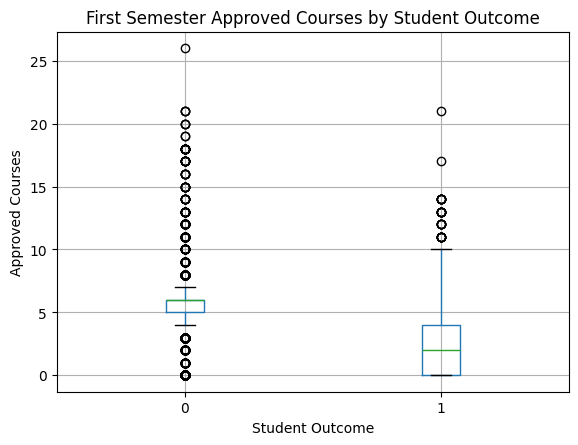

In [12]:
plt.figure(figsize=(8,5))

df.boxplot(
    column='Curricular units 1st sem (approved)',
    by='target_binary'
)

plt.title('First Semester Approved Courses by Student Outcome')
plt.suptitle('')
plt.xlabel('Student Outcome')
plt.ylabel('Approved Courses')
plt.show()

<Figure size 800x500 with 0 Axes>

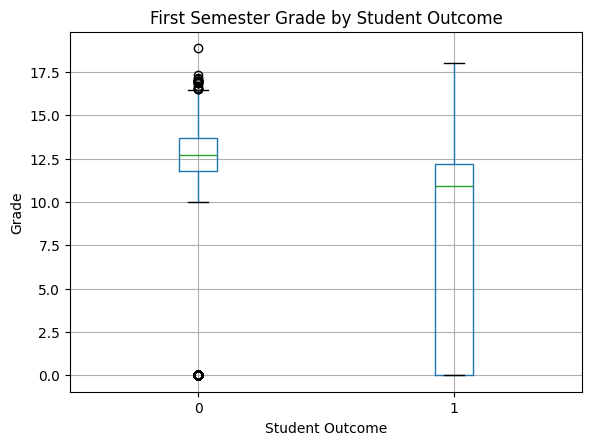

In [13]:
plt.figure(figsize=(8,5))

df.boxplot(
    column='Curricular units 1st sem (grade)',
    by='target_binary'
)

plt.title('First Semester Grade by Student Outcome')
plt.suptitle('')
plt.xlabel('Student Outcome')
plt.ylabel('Grade')
plt.show()

#Feature relationships with dropout

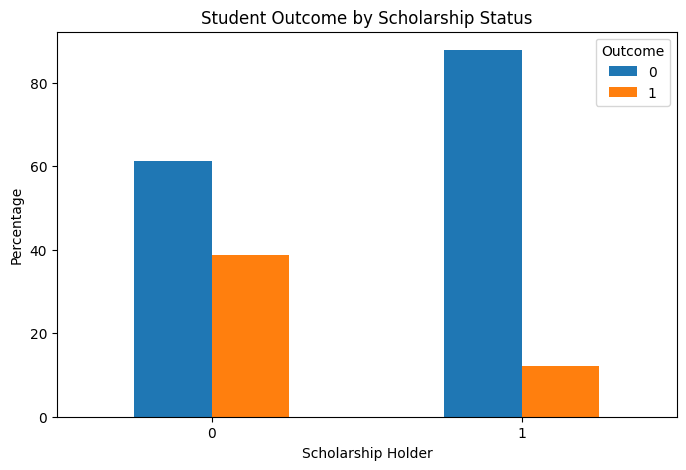

In [ ]:
scholarship_dropout = pd.crosstab(
    df['Scholarship holder'],
    df['target_binary'],
    normalize='index'
) * 100
scholarship_dropout.plot(kind='bar', figsize=(8,5))
plt.title('Student Outcome by Scholarship Status')
plt.xlabel('Scholarship Holder')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Outcome')
plt.show()

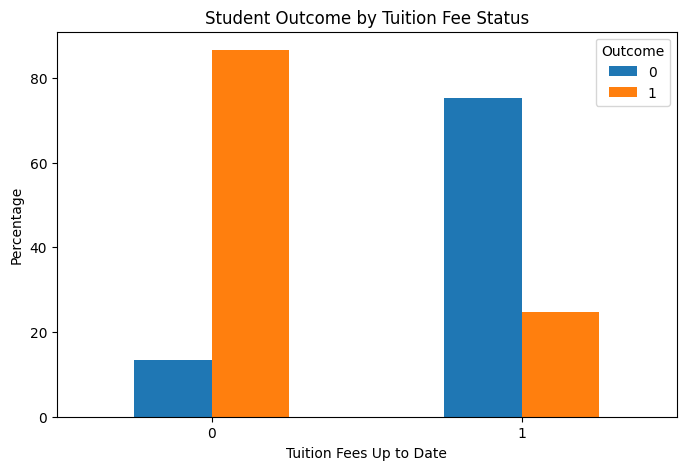

In [ ]:
tuition_dropout = pd.crosstab(
    df['Tuition fees up to date'],
    df['target_binary'],
    normalize='index'
) * 100

tuition_dropout.plot(kind='bar', figsize=(8,5))

plt.title('Student Outcome by Tuition Fee Status')
plt.xlabel('Tuition Fees Up to Date')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Outcome')
plt.show()

#Feature relationship / correlation

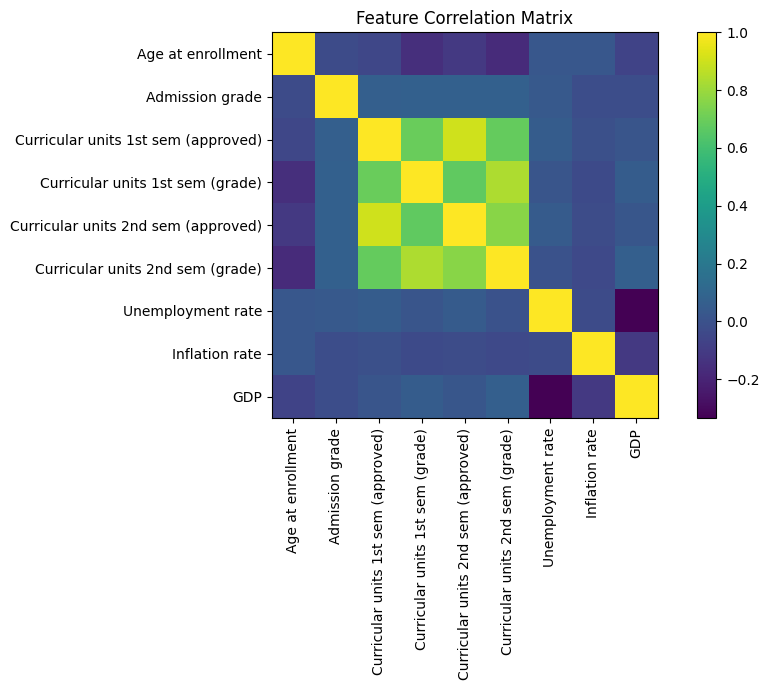

In [ ]:
features = [
    'Age at enrollment','Admission grade','Curricular units 1st sem (approved)','Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)','Curricular units 2nd sem (grade)','Unemployment rate','Inflation rate','GDP']
corr = df[features].corr()
plt.figure(figsize=(10,7))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

#Select and Train the Machine Learning Model

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [21]:
X = df_encoded.drop(columns=['target_binary'])
y = df_encoded['target_binary']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4424, 238)
Target shape: (4424,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (3539, 238)
Testing set shape: (885, 238)

Training target distribution:
target_binary
0    2402
1    1137
Name: count, dtype: int64

Testing target distribution:
target_binary
0    601
1    284
Name: count, dtype: int64


#Create and Train Logistic Regression Model

In [23]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#Predictions

In [24]:
y_pred = model.predict(X_test)

print("Predictions for first 20 test samples:")
print(y_pred[:20])

Predictions for first 20 test samples:
[0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 0 0]


#Prediction probabilities



In [25]:
y_prob = model.predict_proba(X_test)

print("Prediction probabilities for first 20 test samples:")
print(y_prob[:20])

Prediction probabilities for first 20 test samples:
[[0.97814075 0.02185925]
 [0.88617991 0.11382009]
 [0.04478362 0.95521638]
 [0.98379775 0.01620225]
 [0.04502387 0.95497613]
 [0.97202187 0.02797813]
 [0.08554353 0.91445647]
 [0.4977693  0.5022307 ]
 [0.95053596 0.04946404]
 [0.00223867 0.99776133]
 [0.02481945 0.97518055]
 [0.76148995 0.23851005]
 [0.10295723 0.89704277]
 [0.96747076 0.03252924]
 [0.69687901 0.30312099]
 [0.98912331 0.01087669]
 [0.00186629 0.99813371]
 [0.99796516 0.00203484]
 [0.6099859  0.3900141 ]
 [0.9608435  0.0391565 ]]


In [27]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

#Evaluate the Trained Machine Learning Model

Confusion Matrix:
[[572  29]
 [ 68 216]]


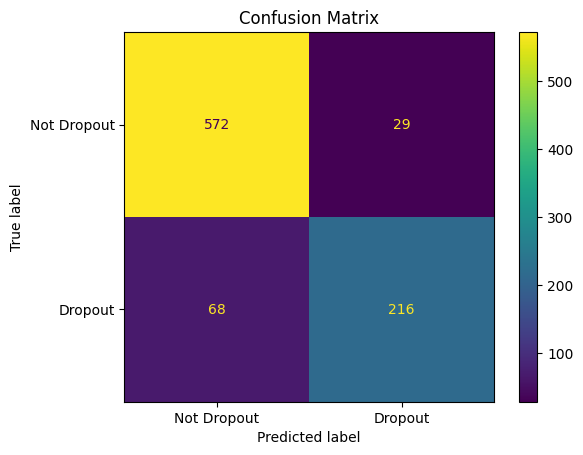

In [28]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Dropout', 'Dropout']
).plot()

plt.title("Confusion Matrix")
plt.show()

#Classification Report

In [29]:
report = classification_report(
    y_test,
    y_pred,
    target_names=['Not Dropout', 'Dropout']
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

 Not Dropout       0.89      0.95      0.92       601
     Dropout       0.88      0.76      0.82       284

    accuracy                           0.89       885
   macro avg       0.89      0.86      0.87       885
weighted avg       0.89      0.89      0.89       885



#Accuracy

In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8903954802259887


#Precision

In [31]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.8816326530612245


#Re-call

In [32]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.7605633802816901


#F1-Score

In [33]:
f1 = f1_score(y_test, y_pred)

print("F1-Score:", f1)

F1-Score: 0.8166351606805293


#ROC-AUC

In [34]:
roc_auc = roc_auc_score(y_test, y_prob[:, 1])

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9320733050549554


#Make Predictions Using the Trained Model

In [35]:
  import pandas as pd
import numpy as np

# Default values from training data
default_values = X_train.median()

def predict_student(
    age,
    admission_grade,
    first_sem_approved,
    first_sem_grade,
    scholarship_holder,
    tuition_up_to_date
):
    # Start with typical training values
    student = default_values.copy()

    # Override selected student information
    student['Age at enrollment'] = age
    student['Admission grade'] = admission_grade
    student['Curricular units 1st sem (approved)'] = first_sem_approved
    student['Curricular units 1st sem (grade)'] = first_sem_grade

    # One-hot encoded binary features
    student['Scholarship holder_1'] = scholarship_holder
    student['Tuition fees up to date_1'] = tuition_up_to_date

    # Make sure the order is exactly the same as training
    student = student[X_train.columns]

    # Convert to DataFrame
    student_df = pd.DataFrame([student])

    # Prediction
    prediction = model.predict(student_df)[0]

    # Probability of dropout
    probability = model.predict_proba(student_df)[0][1]

    # Risk category
    if probability < 0.30:
        risk = "Low Risk"
    elif probability < 0.60:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    return prediction, probability, risk

In [36]:
import ipywidgets as widgets
from IPython.display import display, clear_output

age_input = widgets.IntSlider(
    description='Age:',
    min=17,
    max=70,
    value=20
)

admission_input = widgets.FloatSlider(
    description='Admission Grade:',
    min=0,
    max=200,
    value=130,
    step=0.1
)

approved_input = widgets.IntSlider(
    description='1st Sem Approved:',
    min=0,
    max=30,
    value=5
)

grade_input = widgets.FloatSlider(
    description='1st Sem Grade:',
    min=0,
    max=20,
    value=12,
    step=0.1
)

scholarship_input = widgets.Dropdown(
    options=[
        ('No', 0),
        ('Yes', 1)
    ],
    description='Scholarship:'
)

tuition_input = widgets.Dropdown(
    options=[
        ('Not Up-to-Date', 0),
        ('Up-to-Date', 1)
    ],
    description='Tuition:'
)

predict_button = widgets.Button(
    description='Predict Dropout Risk',
    button_style='primary'
)

output = widgets.Output()

def on_predict_clicked(b):
    with output:
        clear_output()

        prediction, probability, risk = predict_student(
            age_input.value,
            admission_input.value,
            approved_input.value,
            grade_input.value,
            scholarship_input.value,
            tuition_input.value
        )

        print("===== STUDENT DROPOUT PREDICTION =====")
        print(f"Dropout Probability: {probability:.2%}")
        print(f"Risk Category: {risk}")

        if prediction == 1:
            print("Prediction: At Risk of Dropout")
        else:
            print("Prediction: Not At Risk of Dropout")

predict_button.on_click(on_predict_clicked)

display(
    age_input,
    admission_input,
    approved_input,
    grade_input,
    scholarship_input,
    tuition_input,
    predict_button,
    output
)

IntSlider(value=20, description='Age:', max=70, min=17)

FloatSlider(value=130.0, description='Admission Grade:', max=200.0)

IntSlider(value=5, description='1st Sem Approved:', max=30)

FloatSlider(value=12.0, description='1st Sem Grade:', max=20.0)

Dropdown(description='Scholarship:', options=(('No', 0), ('Yes', 1)), value=0)

Dropdown(description='Tuition:', options=(('Not Up-to-Date', 0), ('Up-to-Date', 1)), value=0)

Button(button_style='primary', description='Predict Dropout Risk', style=ButtonStyle())

Output()

#Test Case 1

In [37]:
case1 = predict_student(
    age=19,
    admission_grade=150,
    first_sem_approved=6,
    first_sem_grade=15,
    scholarship_holder=1,
    tuition_up_to_date=1
)

print("===== TEST CASE 1 =====")
print("Prediction:", "At Risk" if case1[0] == 1 else "Not At Risk")
print(f"Dropout Probability: {case1[1]:.2%}")
print("Risk Category:", case1[2])

===== TEST CASE 1 =====
Prediction: Not At Risk
Dropout Probability: 3.60%
Risk Category: Low Risk


#Test Case 2

In [38]:
case2 = predict_student(
    age=25,
    admission_grade=115,
    first_sem_approved=2,
    first_sem_grade=8,
    scholarship_holder=0,
    tuition_up_to_date=0
)

print("===== TEST CASE 2 =====")
print("Prediction:", "At Risk" if case2[0] == 1 else "Not At Risk")
print(f"Dropout Probability: {case2[1]:.2%}")
print("Risk Category:", case2[2])

===== TEST CASE 2 =====
Prediction: At Risk
Dropout Probability: 67.42%
Risk Category: High Risk


#Test Case 3

In [39]:
case3 = predict_student(
    age=30,
    admission_grade=125,
    first_sem_approved=4,
    first_sem_grade=10,
    scholarship_holder=0,
    tuition_up_to_date=1
)

print("===== TEST CASE 3 =====")
print("Prediction:", "At Risk" if case3[0] == 1 else "Not At Risk")
print(f"Dropout Probability: {case3[1]:.2%}")
print("Risk Category:", case3[2])

===== TEST CASE 3 =====
Prediction: Not At Risk
Dropout Probability: 11.81%
Risk Category: Low Risk


In [40]:
import joblib
import pandas as pd

# Save the trained Logistic Regression model
joblib.dump(model, "student_dropout_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [41]:
# Save the feature column names
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

print("Feature columns saved:", len(X_train.columns))

Feature columns saved: 238


In [42]:
# Save default values for features not entered by the user
default_values = X_train.median()

joblib.dump(default_values, "default_values.pkl")

print("Default feature values saved.")

Default feature values saved.
